# Alzheimer Saved Models Comparison
This notebook compares saved models without retraining.
It evaluates test accuracy/loss, creates comparison plots, and draws confusion matrices.
Epoch-wise train/validation curves are not available after kernel restart unless history was saved separately.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

I0000 00:00:1776108125.686749    4364 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776108127.526239    4364 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776108171.881781    4364 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

test_dataset = tf.keras.utils.image_dataset_from_directory(
    'datasets/alzheimer/test',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = test_dataset.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
test_dataset = test_dataset.map(lambda x, y: (tf.cast(x, tf.float32), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print('Classes:', class_names)

Found 1279 files belonging to 4 classes.
Classes: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']


I0000 00:00:1776108200.520579    4364 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [3]:
model_paths = {
    'VGG16': 'outputs/alzheimer/vgg16-alzheimer-vgg16-model.keras',
    'InceptionV3': 'outputs/alzheimer/inception-alzheimer-inception-model.keras',
    'ResNet50': 'outputs/alzheimer/resnet-alzheimer-resnet-model.keras',
    'EfficientNetB0': 'outputs/alzheimer/efficientnet-alzheimer-efficientnet-model.keras',
    'MobileNetV2': 'outputs/alzheimer/mobilenet-alzheimer-mobilenet-model.keras'
}

loaded_models = {}
for name, path in model_paths.items():
    if os.path.exists(path):
        loaded_models[name] = tf.keras.models.load_model(path)
    else:
        print('Missing model:', path)

print('Loaded models:', list(loaded_models.keys()))

/mnt/d/B.Tech/ProjeX/MachineLearning/Deeplearning/.ubuntu-venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
E0000 00:00:1776108213.717153    4364 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Loaded models: ['VGG16', 'InceptionV3', 'ResNet50', 'EfficientNetB0', 'MobileNetV2']


In [4]:
y_true_batches = []
for _, y_batch in test_dataset:
    y_true_batches.append(np.argmax(y_batch.numpy(), axis=1))
y_true = np.concatenate(y_true_batches, axis=0)

results_rows = []
confusion_matrices = {}

for model_name, model in loaded_models.items():
    print(f'Running {model_name}...')

    start_time = time.time()
    probs = model.predict(test_dataset, verbose=0)
    inference_time = time.time() - start_time

    y_pred = np.argmax(probs, axis=1)
    y_true_onehot = tf.one_hot(y_true, depth=num_classes)
    losses = tf.keras.losses.categorical_crossentropy(y_true_onehot, probs)
    eval_loss = float(tf.reduce_mean(losses).numpy())
    eval_acc = float(np.mean(y_pred == y_true))

    cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()
    confusion_matrices[model_name] = cm

    tp = np.diag(cm).astype(np.float64)
    fp = np.sum(cm, axis=0) - tp
    fn = np.sum(cm, axis=1) - tp

    precision_per_class = tp / np.maximum(tp + fp, 1e-12)
    recall_per_class = tp / np.maximum(tp + fn, 1e-12)
    f1_per_class = 2 * precision_per_class * recall_per_class / np.maximum(precision_per_class + recall_per_class, 1e-12)

    macro_precision = float(np.mean(precision_per_class))
    macro_recall = float(np.mean(recall_per_class))
    macro_f1 = float(np.mean(f1_per_class))

    file_size_mb = os.path.getsize(model_paths[model_name]) / (1024 * 1024)

    results_rows.append({
        'Model': model_name,
        'Test Accuracy': eval_acc,
        'Test Loss': eval_loss,
        'Macro Precision': macro_precision,
        'Macro Recall': macro_recall,
        'Macro F1': macro_f1,
        'Parameters': int(model.count_params()),
        'Model Size (MB)': float(file_size_mb),
        'Inference Time (s)': float(inference_time)
    })

    print(f'Done {model_name} | acc={eval_acc:.4f} | loss={eval_loss:.4f} | time={inference_time:.2f}s')

Running VGG16...


I0000 00:00:1776108221.999680    4839 service.cc:153] XLA service 0x7463b8031af0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776108221.999751    4839 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776108222.114179    4839 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776108222.331585    4839 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776108232.396016    4839 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Done VGG16 | acc=0.7733 | loss=0.5255 | time=19.19s
Running InceptionV3...
Done InceptionV3 | acc=0.7021 | loss=0.6605 | time=71.97s
Running ResNet50...
Done ResNet50 | acc=0.7443 | loss=0.5758 | time=30.06s
Running EfficientNetB0...
Done EfficientNetB0 | acc=0.6450 | loss=0.7325 | time=109.09s
Running MobileNetV2...
Done MobileNetV2 | acc=0.7295 | loss=0.6043 | time=49.27s


In [5]:
comparison_df = pd.DataFrame(results_rows).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
display(comparison_df.style.format({
    'Test Accuracy': '{:.4f}',
    'Test Loss': '{:.4f}',
    'Macro Precision': '{:.4f}',
    'Macro Recall': '{:.4f}',
    'Macro F1': '{:.4f}',
    'Model Size (MB)': '{:.2f}',
    'Inference Time (s)': '{:.3f}'
}))

,Model,Test Accuracy,Test Loss,Macro Precision,Macro Recall,Macro F1,Parameters,Model Size (MB),Inference Time (s)
0,VGG16,0.7733,0.5255,0.8266,0.7102,0.7534,14847044,58.75,19.193
1,ResNet50,0.7443,0.5758,0.7701,0.6433,0.6898,24113284,100.65,30.061
2,MobileNetV2,0.7295,0.6043,0.7730,0.5932,0.6452,2586948,15.46,49.269
3,InceptionV3,0.7021,0.6605,0.6942,0.6242,0.6496,22328356,94.26,71.973
4,EfficientNetB0,0.6450,0.7325,0.6564,0.4731,0.5154,4378535,22.54,109.089


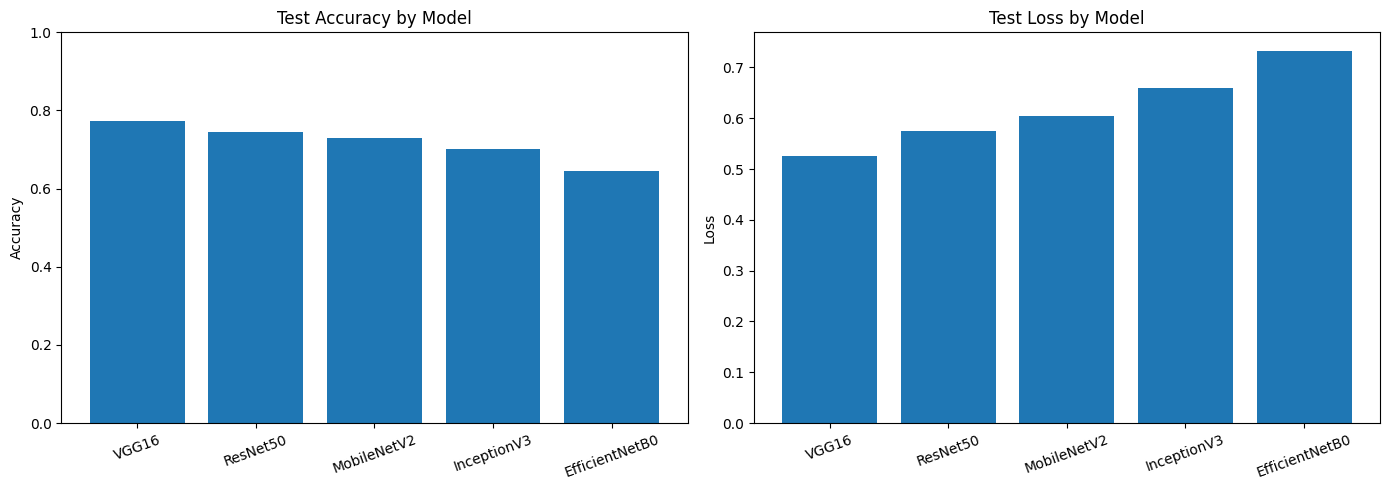

In [6]:
if not comparison_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(comparison_df['Model'], comparison_df['Test Accuracy'])
    axes[0].set_title('Test Accuracy by Model')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1.0)
    axes[0].tick_params(axis='x', rotation=20)

    axes[1].bar(comparison_df['Model'], comparison_df['Test Loss'])
    axes[1].set_title('Test Loss by Model')
    axes[1].set_ylabel('Loss')
    axes[1].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()

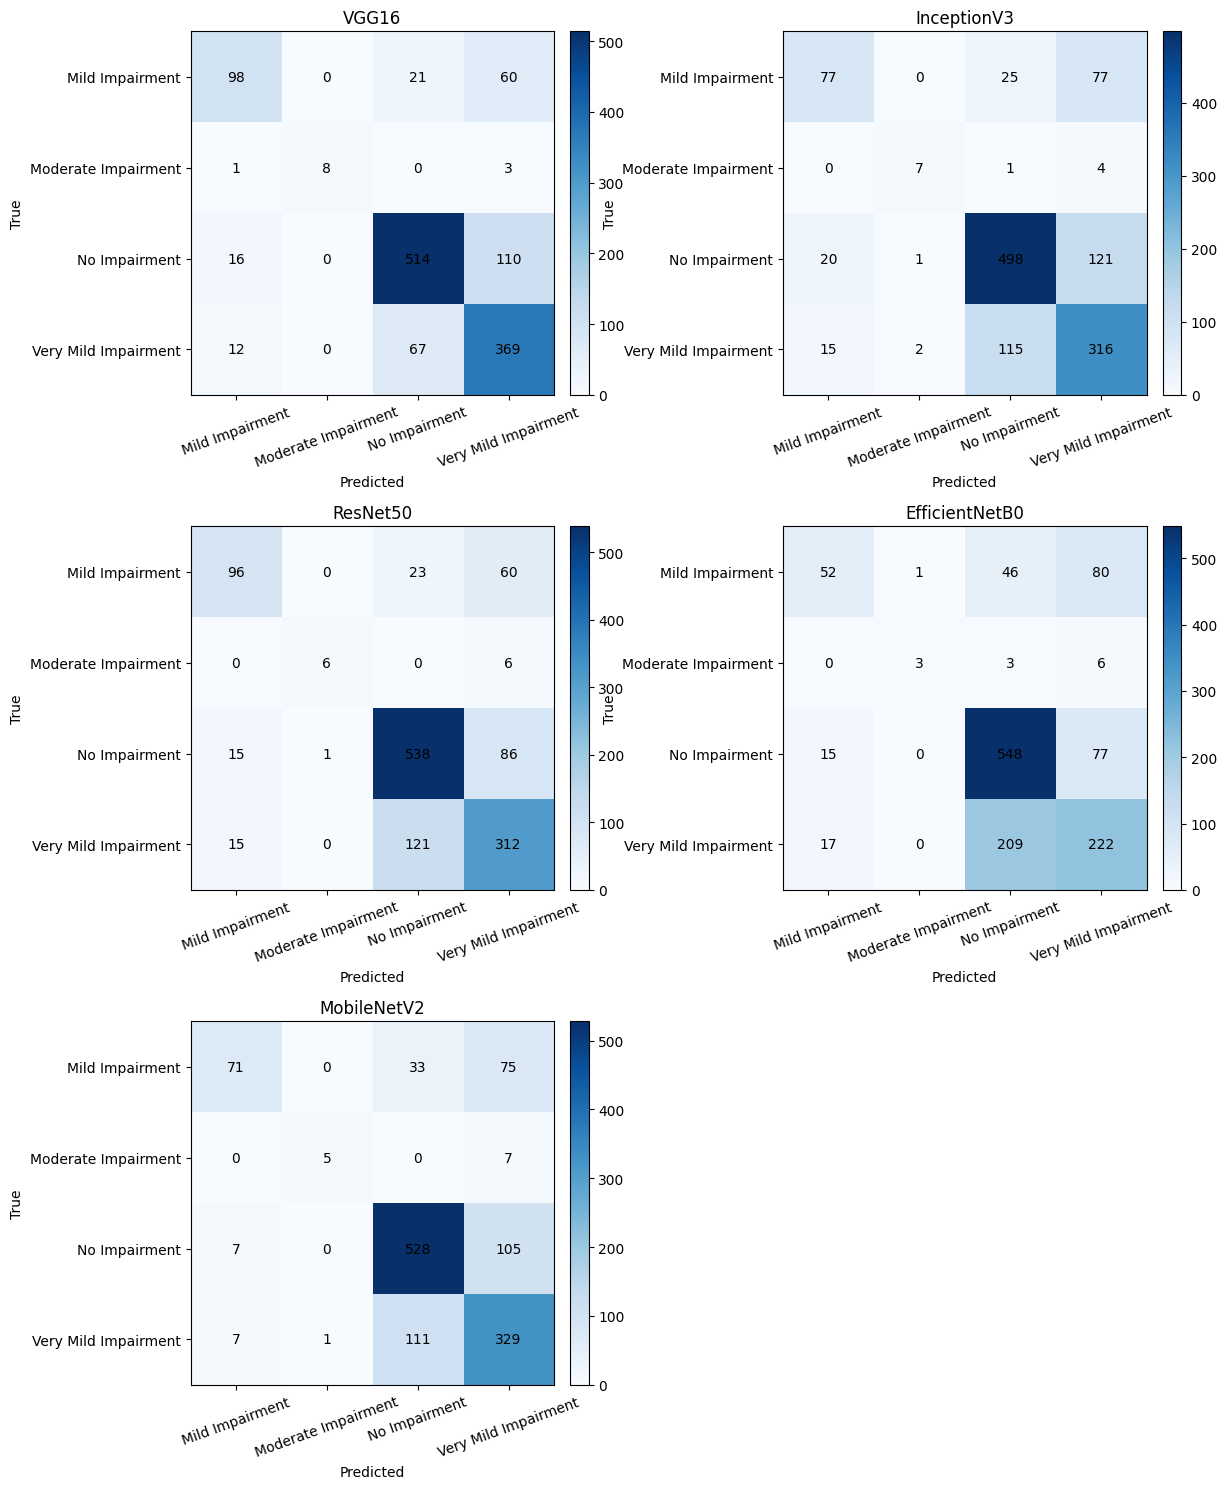

In [7]:
if confusion_matrices:
    n_models = len(confusion_matrices)
    cols = 2
    rows = int(np.ceil(n_models / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for idx, (model_name, cm) in enumerate(confusion_matrices.items()):
        ax = axes[idx]
        im = ax.imshow(cm, cmap='Blues')
        ax.set_title(model_name)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_xticks(range(num_classes))
        ax.set_yticks(range(num_classes))
        ax.set_xticklabels(class_names, rotation=20)
        ax.set_yticklabels(class_names)

        for i in range(num_classes):
            for j in range(num_classes):
                ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for k in range(idx + 1, len(axes)):
        axes[k].axis('off')

    plt.tight_layout()
    plt.show()

In [8]:
os.makedirs('outputs/alzheimer', exist_ok=True)
comparison_df.to_csv('outputs/alzheimer/saved_models_comparison.csv', index=False)
print('Saved:', 'outputs/alzheimer/saved_models_comparison.csv')

Saved: outputs/alzheimer/saved_models_comparison.csv
